<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#75DFC1">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Feature Engineering/Encodage cyclique </h2></center>
<hr style="border-width:2px;border-color:#75DFC1">

### Chargement des données PACA (METEO / ENERGIE)

Cette étape consiste à charger le fichier **"paca_meteo_energie.csv"** contenant les données météorologiques et radiatives régionales pour la région PACA avec une résolution temporelle de **30 minutes**.

Les variables disponibles dans ce jeu de données comprennent notamment:

- **`azimuth`** : azimut solaire (en degrés), indiquant la direction du soleil par rapport au nord (0–360° selon la convention).  
- **`altitude`** : altitude solaire (en degrés), représentant l'élévation du soleil au-dessus de l'horizon (valeurs négatives durant la nuit).  
- **`Temperature`** *(souvent `T2M`)* : température de l'air à 2 mètres du sol (en °C ou en K selon la source ; une vérification des unités est nécessaire).  
- **`GHI`** (*Global Horizontal Irradiance*) : irradiance globale reçue sur un plan horizontal (composantes directe et diffuse) exprimée en Wh/m².  
- **`BHI`** (*Beam Horizontal Irradiance*) : composante directe du rayonnement solaire projetée sur le plan horizontal (Wh/m²).  
- **`DHI`** (*Diffuse Horizontal Irradiance*) : composante diffuse du rayonnement solaire reçue sur un plan horizontal (Wh/m²).  
- **`BNI`** (*Beam Normal Irradiance*) : irradiance directe normale, reçue sur un plan perpendiculaire aux rayons solaires (Wh/m²).  
- **`Vitesse_Vent`** *(souvent `V2M`)* : vitesse du vent mesurée à 2 mètres du sol (m/s).  
- **`Nebulosite`** *(souvent `cloud_AMT`)* : nébulosité ou fraction de couverture nuageuse (exprimée selon les produits en fraction, pourcentage ou indice adimensionnel).  
- **`Humidite`** : humidité de l'air (généralement humidité relative en %, ou humidité spécifique selon la source).  
- **`Clear_sky_GHI`** : irradiance globale horizontale en conditions de ciel clair, utilisée comme référence théorique sans nuages (Wh/m²).  
- **`Clear_sky_BHI`** : composante directe horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_DHI`** : composante diffuse horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_BNI`** : irradiance directe normale en conditions de ciel clair (Wh/m²).  
- **`TOA`** (*Top Of Atmosphere*) : rayonnement solaire incident au sommet de l'atmosphère (Wh/m²), utilisé pour le contrôle de cohérence et la normalisation des séries.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion

# Chargement du jeu de données brut (2020–2024)
df = pd.read_csv("paca_meteo_energie.csv", parse_dates=["Date"])

# Aperçu des premières lignes
display(df.head())

# Informations générales sur la structure des données
df.info()

,Date,Consommation,Solaire,Ech._physiques,tco,tch,solar_azimuth_region,solar_altitude_region,temperature_region,ghi_region,...,dhi_region,dni_region,wind_speed_region,cloud_cover_region,humidity_region,clear_sky_ghi_region,clear_sky_bhi_region,clear_sky_dhi_region,clear_sky_dni_region,toa_irradiance_region
0,2019-12-31 23:00:00+00:00,6123.0,0.0,3332.0,0.0,0.0,334.860133,-67.658747,3.23070,0.0,...,0.0,0.0,1.34110,23.8652,85.2922,0.0,0.0,0.0,0.0,0.0
1,2019-12-31 23:30:00+00:00,5907.0,0.0,2837.0,0.0,0.0,353.234530,-69.154695,3.38585,0.0,...,0.0,0.0,1.36150,24.5565,83.1551,0.0,0.0,0.0,0.0,0.0
2,2020-01-01 00:00:00+00:00,5724.0,0.0,2668.0,0.0,0.0,12.560776,-68.877374,3.54100,0.0,...,0.0,0.0,1.38190,25.2478,81.0180,0.0,0.0,0.0,0.0,0.0
3,2020-01-01 00:30:00+00:00,5749.0,0.0,2754.0,0.0,0.0,30.183447,-66.891776,3.60800,0.0,...,0.0,0.0,1.33655,15.2331,79.0697,0.0,0.0,0.0,0.0,0.0
4,2020-01-01 01:00:00+00:00,5700.0,0.0,2886.0,0.0,0.0,44.705668,-63.589084,3.67500,0.0,...,0.0,0.0,1.29120,5.2184,77.1214,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87696 entries, 0 to 87695
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   Date                   87696 non-null  datetime64[ns, UTC]
 1   Consommation           87696 non-null  float64            
 2   Solaire                87696 non-null  float64            
 3   Ech._physiques         87696 non-null  float64            
 4   tco                    87696 non-null  float64            
 5   tch                    87696 non-null  float64            
 6   solar_azimuth_region   87696 non-null  float64            
 7   solar_altitude_region  87696 non-null  float64            
 8   temperature_region     87696 non-null  float64            
 9   ghi_region             87696 non-null  float64            
 10  bhi_region             87696 non-null  float64            
 11  dhi_region             87696 non-null  float64        

## Définition de la variable cible

La production photovoltaïque est largement déterminée par des effets géométriques prévisibles
(`heure`, `saison`). Un modèle peut donc bien prédire la production moyenne tout en manquant
les variations rapides, qui sont pourtant les plus critiques pour le réseau.

Ces variations sont décrites par les **rampes de production**, qui mesurent la vitesse de
changement de la puissance photovoltaïque dans le temps.

La variabilité à 30 minutes est définie par la rampe normalisée :

$$
V(t) = \left|\frac{P(t) - P(t-\Delta t)}{P_{\text{capacité}}}\right|
     = \Big|\mathrm{TCH}(t) - \mathrm{TCH}(t-\Delta t)\Big|
     = \Big|\text{Delta\_TCH}(t)\Big|
$$

où :
- $P(t)$ est la production photovoltaïque régionale (MW) à temps $t$,
- $\mathrm{TCH}(t)$ est la production photovoltaïque normalisée $\dfrac{P(t)}{P_{\text{capacité}}}$
- $P_{\text{capacité}}$ la capacité installée totale (MW),
- $\Delta t = 30$ minutes.

**Interprétation :**
- $\text{Delta\_TCH}(t) > 0$ : augmentation rapide de la production (dissipation des nuages),
- $\text{Delta\_TCH}(t) < 0$ : chute rapide de la production (passage nuageux),
- grande amplitude de $V(t)$ : forte variabilité et stress accru pour le réseau.

Cette formulation mesure directement les rampes de puissance, est indépendante de la taille du parc,
robuste aux effets de niveau (saison, heure) et cohérente avec les indicateurs utilisés dans la
littérature énergie et réseaux..


In [2]:
# Rampe signée de la production normalisée
df["dtch_dt"] = df["tch"].diff()

# Variable cible : variabilité à 30 minutes
df["target_variability"] = df["dtch_dt"].abs()

## Variables explicatives
### Choix de l'irradiance solaire

**BNI – Beam (Direct) Normal Irradiance**  
Le $BNI$ correspond au rayonnement solaire direct mesuré sur un plan perpendiculaire aux rayons du soleil.  
Sur un plan horizontal, sa contribution s'écrit :
$$
BHI = BNI \cdot \cos(\theta_z)
$$
où $\theta_z = \dfrac{\pi}{2} - \alpha$ est l'angle zénithal solaire et $\alpha$ l'**altitude solaire**, définie comme l'angle entre le soleil et l'horizon.  
Le $BNI$ dépend donc fortement de la position instantanée du soleil et suppose une orientation optimale du capteur. Or, les panneaux photovoltaïques fixes ne sont pas toujours perpendiculaires aux rayons solaires et ne suivent généralement pas le soleil.

**GHI – Global Horizontal Irradiance**  
Le $GHI$ représente le rayonnement solaire total reçu sur un plan horizontal et s'exprime par :
$$
GHI = BHI + DHI = BNI \cdot \cos(\theta_z) + DHI
$$
où $DHI$ est l'irradiance diffuse horizontale.  
Le $GHI$ intègre ainsi les composantes directe et diffuse du rayonnement et décrit plus fidèlement l'irradiation réellement reçue par les panneaux photovoltaïques standards.

**Choix méthodologique**  
Dans notre projet, nous adoptons le **GHI** comme variable d'entrée principale, car il permet une analyse plus représentative et plus robuste de la variabilité de la production solaire à partir de données ouvertes.

### Variations d'irradiance et de nébulosité

Les rampes de production photovoltaïque sont principalement déclenchées par des variations
rapides de l'irradiance solaire, généralement associées aux passages nuageux.

On considère donc les variations temporelles de l'irradiance globale et de la nébulosité :

$$
\Delta GHI(t) = GHI(t) - GHI(t-\Delta t)
$$

$$
\Delta \text{Nebulosite}(t) =
\text{Nebulosite\_region}(t) -
\text{Nebulosite\_region}(t-\Delta t)
$$
avec $\Delta t = 30$ minutes.

Ces variables capturent directement les transitions nuageuses responsables des rampes
de production photovoltaïque.



In [3]:
df["dghi_dt"] = df["ghi_region"].diff()
df["dcloud_dt"] = df["cloud_cover_region"].diff()


### Mémoire du système (lags)

La production photovoltaïque et les variables météorologiques associées ne réagissent pas de
manière instantanée aux perturbations atmosphériques. Le système présente une **mémoire
temporelle**, liée à l'inertie physique des installations photovoltaïques et à la dynamique
des conditions radiatives.

Afin de représenter cette dépendance temporelle, des **variables retardées (lags)** de la
production photovoltaïque et de l'irradiance globale sont introduites. Ces variables
permettent de tenir compte de l'état récent du système, qui influence directement son
évolution à court terme.

On considère les lags suivants :

- pour la production photovoltaïque :
$$ TCH(t-1), \quad TCH(t-2) $$

- pour l'irradiance globale :
$$ \text{GHI\_region}(t-1), \quad \text{GHI\_region}(t-2) $$

où chaque décalage correspond à un pas de temps de $\Delta t = 30$ minutes.

Ces variables permettent notamment :

- de capturer l'inertie du système photovoltaïque à l'échelle régionale,
- de représenter les rampes de production déjà engagées,
- de modéliser l'évolution récente de l'irradiance, souvent plus informative que sa valeur
instantanée,
- d'améliorer la capacité des modèles à anticiper les variations rapides de la production.

L'introduction de ces lags constitue ainsi une représentation simple, robuste et
physiquement cohérente de la mémoire du système, indispensable pour la modélisation de la
variabilité photovoltaïque à court terme.


**Implémentation :** les variables retardées sont obtenues à l'aide de la fonction  
`DataFrame.shift()`, qui décale les séries temporelles d'un nombre donné de pas
($\Delta t = 30$ minutes) sans altérer les données originales.

**Référence :** **[`DataFrame.shift(periods=1, axis=0)`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html)**


## Utilisation des rampes retardées (lagged ramps) et de la mémoire du système pour la prévision photovoltaïque

L'objectif est de **prédire la variabilité à court terme** de la production photovoltaïque (PV) — en particulier les **rampes** (variations rapides) — en exploitant l'information contenue dans l'évolution récente du système. En effet, la production PV et les conditions radiatives ne réagissent pas instantanément aux perturbations atmosphériques : le système présente une **mémoire temporelle**, liée à la dynamique continue des nuages (advection) et à l'inertie de la réponse PV.

Dans cette étude, les données sont disponibles à une **résolution temporelle de 30 minutes** (\(\Delta t = 30\) min). Nous introduisons donc des **variables retardées (lags)** afin de représenter l'état récent du système, qui influence directement son évolution à court terme :
- **Rampes retardées de production PV** :  
  `lag1` $\equiv \text{rampe}(t-1)$ = rampe à $(t-30\,\text{min})$  
  `lag2` $\equiv \text{rampe}(t-2)$ = rampe à $(t-60\,\text{min})$
- **Lags de production PV** :  
  $$
  TCH(t-1), \quad TCH(t-2)
  $$
- **Lags d'irradiance globale régionale** :  
  $$ \mathrm{GHI_region}(t-1), \quad \mathrm{GHI_region}(t-2)$$

Ce choix est **physiquement pertinent** : les rampes PV sont généralement **autocorrélées** et présentent un effet de **persistance**. Par exemple, si la production était en forte baisse il y a 30 minutes, il est probable que la tendance se prolonge à l'instant présent.

L'idée générale du modèle peut être formulée comme suit :
```text
rampe(t) ≈ f( rampe(t−1), rampe(t−2), TCH(t−1), TCH(t−2), GHI_region(t−1), GHI_region(t−2), météo, position du soleil )
```   
L'introduction de ces lags permet notamment :
- de capturer l'inertie du système photovoltaïque à l'échelle régionale,
- de représenter les rampes de production déjà engagées,
- de modéliser l'évolution récente de l'irradiance, souvent plus informative que sa valeur
instantanée,
- d'améliorer la capacité des modèles à anticiper les variations rapides de la production.

**Implémentation :** les variables retardées sont obtenues à l'aide de la fonction  
`DataFrame.shift()`, qui décale les séries temporelles d'un nombre donné de pas
(\(\Delta t = 30\) minutes) sans altérer les données originales.

**Référence :** **[`DataFrame.shift(periods=1, axis=0)`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html)**

In [4]:
# --------------------------------------------------
# Décalages temporels (lags) des variables régionales
# --------------------------------------------------

# Lags de l'irradiance globale régionale
df["ghi_lag_1"] = df["ghi_region"].shift(1)
df["ghi_lag_2"] = df["ghi_region"].shift(2)

# Lags de la nébulosité régionale
df["cloud_lag_1"] = df["cloud_cover_region"].shift(1)
df["cloud_lag_2"] = df["cloud_cover_region"].shift(2)

df.loc[
    df["ghi_region"] > 0, [
        "Date",
        "ghi_region",
        "ghi_lag_1",
        "ghi_lag_2",
        "cloud_cover_region",
        "cloud_lag_1",
        "cloud_lag_2",
    ]
]

#df.loc[df.GHI_region > 0, ['Date', 'GHI_region', 'GHI(t-1)', 'GHI(t-2)', 'Nebulosite_region', 'Nebulosite(t-1)', 'Nebulosite(t-2)']]

,Date,ghi_region,ghi_lag_1,ghi_lag_2,cloud_cover_region,cloud_lag_1,cloud_lag_2
16,2020-01-01 07:00:00+00:00,0.005586,0.000000,0.000000,25.32550,28.36505,31.40460
17,2020-01-01 07:30:00+00:00,9.671917,0.005586,0.000000,22.04280,25.32550,28.36505
18,2020-01-01 08:00:00+00:00,41.024514,9.671917,0.005586,18.76010,22.04280,25.32550
19,2020-01-01 08:30:00+00:00,76.905586,41.024514,9.671917,15.77695,18.76010,22.04280
20,2020-01-01 09:00:00+00:00,111.046611,76.905586,41.024514,12.79380,15.77695,18.76010
...,...,...,...,...,...,...,...
87678,2024-12-31 14:00:00+00:00,130.798456,157.195193,159.643778,21.69320,22.59640,23.49960
87679,2024-12-31 14:30:00+00:00,98.582465,130.798456,157.195193,21.22015,21.69320,22.59640
87680,2024-12-31 15:00:00+00:00,63.783018,98.582465,130.798456,20.74710,21.22015,21.69320
87681,2024-12-31 15:30:00+00:00,29.847971,63.783018,98.582465,19.58040,20.74710,21.22015


### Indicateurs statistiques locaux de variabilité

Les variables introduites précédemment permettent de capturer la dynamique instantanée de la production photovoltaïque à travers les rampes ainsi que son inertie à court terme via les variables retardées. Afin de compléter cette description, des indicateurs statistiques locaux ont été ajoutés pour caractériser le régime de variabilité de la production et de l’irradiance sur des horizons temporels de quelques heures.

Soit $x(t)$ une série temporelle représentant la production photovoltaïque ou l’irradiance solaire à l’instant $t$. La **moyenne glissante** sur une fenêtre temporelle de longueur $T$ (exprimée en nombre de pas de temps) est définie par :

$$
\mu_T(t) = \frac{1}{T}\sum_{k=0}^{T-1} x(t-k)
$$

Cette moyenne glissante fournit une estimation du niveau local de référence du signal, en lissant les fluctuations rapides et en mettant en évidence la tendance récente.

La variabilité locale du signal est quant à elle caractérisée par l’**écart-type glissant**, défini par :

$$
\sigma_T(t) = \sqrt{\frac{1}{T}\sum_{k=0}^{T-1}\left(x(t-k) - \mu_T(t)\right)^2}
$$

L’écart-type glissant quantifie l’intensité des fluctuations autour de la moyenne locale. Des valeurs élevées de $\sigma_T(t)$ traduisent des périodes marquées par une forte intermittence, tandis que des valeurs faibles correspondent à des régimes de production plus stables.

Dans le cadre de ce projet, ces indicateurs sont calculés sur des fenêtres de **2 heures** et **4 heures**, afin de capturer des régimes de variabilité à différentes échelles temporelles. Ils apportent une information complémentaire aux rampes instantanées, en fournissant une vision synthétique de la variabilité locale du système, exploitable dans un cadre de modélisation prédictive.

In [5]:
# -------------------------------------------------------------------
# Indicateurs statistiques locaux de variabilité
# Fenêtres temporelles : 2h et 4h (pas de temps = 30 minutes)
# -------------------------------------------------------------------

# Nombre de pas de temps correspondant aux fenêtres
window_2h = 4   # 2 heures = 4 pas de 30 minutes
window_4h = 8   # 4 heures = 8 pas de 30 minutes

# === Moyennes glissantes ===

# Production photovoltaïque
df["prod_mean_2h"] = (
    df["tch"]
    .rolling(window=window_2h)
    .mean()
)

df["prod_mean_4h"] = (
    df["tch"]
    .rolling(window=window_4h)
    .mean()
)

# Irradiance solaire
df["ghi_mean_2h"] = (
    df["ghi_region"]
    .rolling(window=window_2h)
    .mean()
)

df["ghi_mean_4h"] = (
    df["ghi_region"]
    .rolling(window=window_4h)
    .mean()
)

# === Écarts-types glissants ===

# Production photovoltaïque
df["prod_std_2h"] = (
    df["tch"]
    .rolling(window=window_2h)
    .std()
)

df["prod_std_4h"] = (
    df["tch"]
    .rolling(window=window_4h)
    .std()
)

# Irradiance solaire
df["ghi_std_2h"] = (
    df["ghi_region"]
    .rolling(window=window_2h)
    .std()
)

df["ghi_std_4h"] = (
    df["ghi_region"]
    .rolling(window=window_4h)
    .std()
)

## Encodage temporel

La variabilité de la production photovoltaïque dépend fortement de phénomènes cycliques
(alt. jour/nuit, saisonnalité). Utiliser des variables temporelles discrètes (heure, jour
de l'année) peut introduire des discontinuités artificielles (23h proche de 0h, 31/12 proche
de 01/01). Pour préserver cette continuité, on adopte un [**encodage cyclique sinusoïdal**](https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/).

### Encodage de l'heure de la journée et du jour de l'année

$$
\text{sin\_hour}(t) = \sin\left( \frac{2\cdot\pi \cdot \text{hour}(t)}{24} \right), \quad
\text{cos\_hour}(t) = \cos\left( \frac{2\cdot\pi \cdot \text{hour}(t)}{24} \right)
$$
où $\text{hour}(t)$ est une variable continue (heures + minutes).

$$
\text{sin\_day}(t) = \sin\left( \frac{2\cdot\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right), \quad
\text{cos\_day}(t) = \cos\left( \frac{2\cdot\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right)
$$

où $N_{\text{jours}} = 365$ ou $366$ (années bissextiles).

Cet encodage respecte la périodicité solaire, évite les ruptures numériques et améliore la généralisation du modèle sur des périodes non vues.


In [6]:
# Extraction des composantes calendaires
df['year']  = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day']   = df['Date'].dt.day
df['hour']  = df['Date'].dt.hour

# Encodage cyclique de l'heure (continu, heure + minutes)
hour = df['hour'] + df['Date'].dt.minute / 60
df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
df['cos_hour'] = np.cos(2 * np.pi * hour / 24)

# Encodage cyclique du jour de l'année (avec années bissextiles)
doy = df['Date'].dt.dayofyear - 1
year_len = np.where(df['Date'].dt.is_leap_year, 366, 365)
df['sin_day'] = np.sin(2 * np.pi * doy / year_len)
df['cos_day'] = np.cos(2 * np.pi * doy / year_len)

# Encodage cyclique du jour de la semaine (effet WE/jours ouvrés)
dow = df['Date'].dt.dayofweek
df['sin_dow'] = np.sin(2 * np.pi * dow / 7)
df['cos_dow'] = np.cos(2 * np.pi * dow / 7)

# Vérification
df[['Date', 'day', 'sin_hour', 'cos_hour', 'sin_day', 'cos_day']].head()


,Date,day,sin_hour,cos_hour,sin_day,cos_day
0,2019-12-31 23:00:00+00:00,31,-0.258819,0.965926,-0.017213,0.999852
1,2019-12-31 23:30:00+00:00,31,-0.130526,0.991445,-0.017213,0.999852
2,2020-01-01 00:00:00+00:00,1,0.000000,1.000000,0.000000,1.000000
3,2020-01-01 00:30:00+00:00,1,0.130526,0.991445,0.000000,1.000000
4,2020-01-01 01:00:00+00:00,1,0.258819,0.965926,0.000000,1.000000


#### Visualisation de l'encodage cyclique

La projection sinus/cosinus permet de représenter la cyclicité temporelle sur le cercle unité, en préservant la continuité aux frontières des cycles journaliers et annuels.


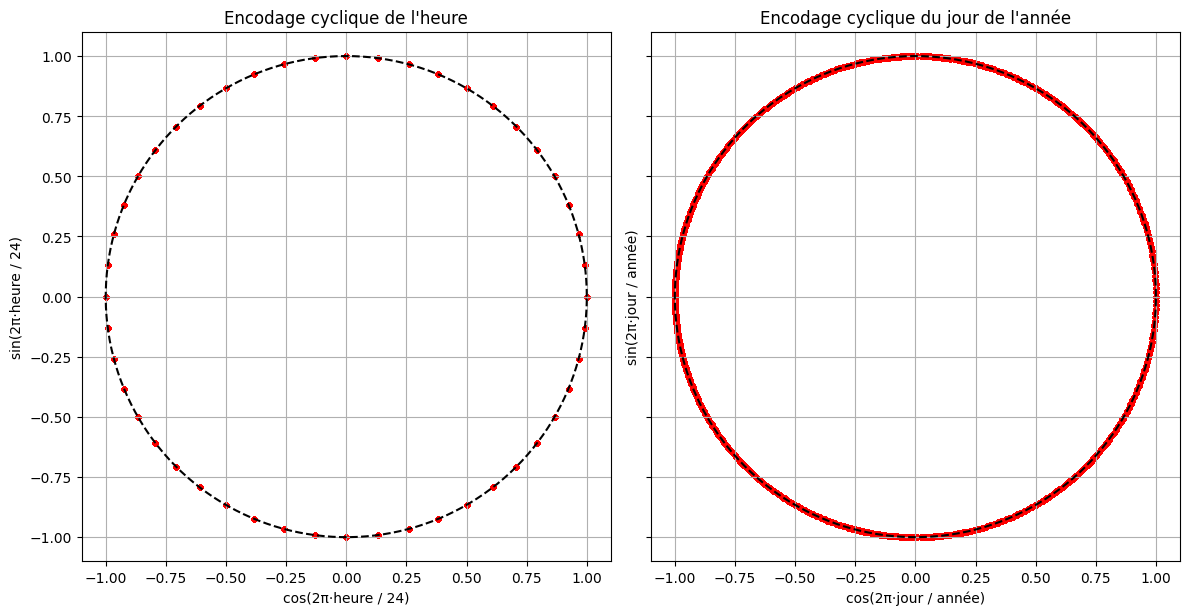

In [7]:
theta = np.linspace(0, 2*np.pi, 360)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# --- Subplot 1 : Encodage cyclique de l'heure ---
ax = axes[0]
ax.scatter(df['cos_hour'], df['sin_hour'], alpha=0.5, s=10, c='red')
ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
ax.set_xlabel("cos(2π·heure / 24)")
ax.set_ylabel("sin(2π·heure / 24)")
ax.set_title("Encodage cyclique de l'heure")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# --- Subplot 2 : Encodage cyclique du jour de l'année ---
ax = axes[1]
ax.scatter(df['cos_day'], df['sin_day'], alpha=0.5, s=10, c='red')
ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
ax.set_xlabel("cos(2π·jour / année)")
ax.set_ylabel("sin(2π·jour / année)")
ax.set_title("Encodage cyclique du jour de l'année")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


Les points rouges sont répartis sur le cercle unité, illustrant le caractère cyclique des variables temporelles : les heures proches de minuit (23 h et 0 h) ainsi que les jours situés aux extrémités de l'année (31 décembre et 1er janvier) restent voisins dans l'espace encodé, contrairement à un encodage linéaire.


#### Continuité de l'encodage cyclique

Les composantes sinus et cosinus varient de manière continue au cours de la journée.


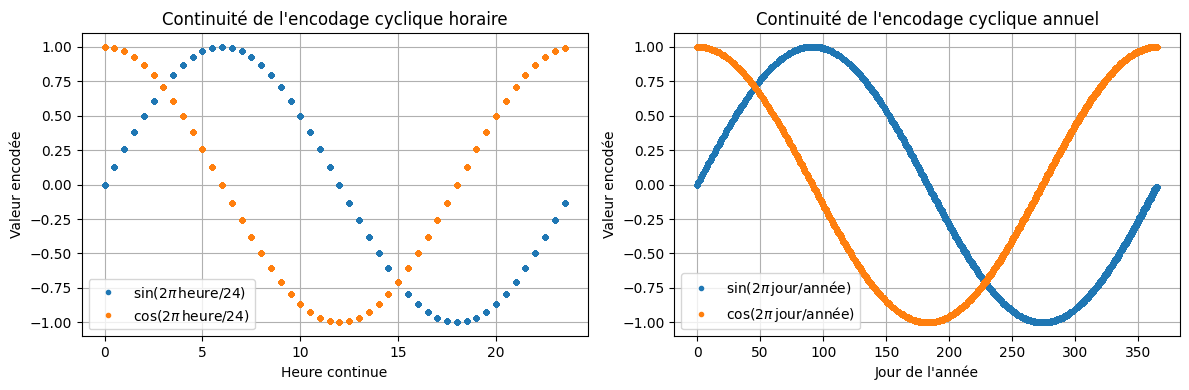

In [8]:
plt.figure(figsize=(12, 4))

# --- Plot 1 : Encodage cyclique de l'heure ---
plt.subplot(1, 2, 1)
plt.plot(hour, df['sin_hour'], '.', label=r'$\sin(2\pi\,\mathrm{heure}/24)$')
plt.plot(hour, df['cos_hour'], '.', label=r'$\cos(2\pi\,\mathrm{heure}/24)$')
plt.xlabel("Heure continue")
plt.ylabel("Valeur encodée")
plt.title("Continuité de l'encodage cyclique horaire")
plt.legend()
plt.grid(True)

# --- Plot 2 : Encodage cyclique du jour de l'année ---
plt.subplot(1, 2, 2)
plt.plot(doy, df['sin_day'], '.', label=r'$\sin(2\pi\,\mathrm{jour}/\mathrm{année})$')
plt.plot(doy, df['cos_day'], '.', label=r'$\cos(2\pi\,\mathrm{jour}/\mathrm{année})$')
plt.xlabel("Jour de l'année")
plt.ylabel("Valeur encodée")
plt.title("Continuité de l'encodage cyclique annuel")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#### Continuité autour de minuit et du changement d'année


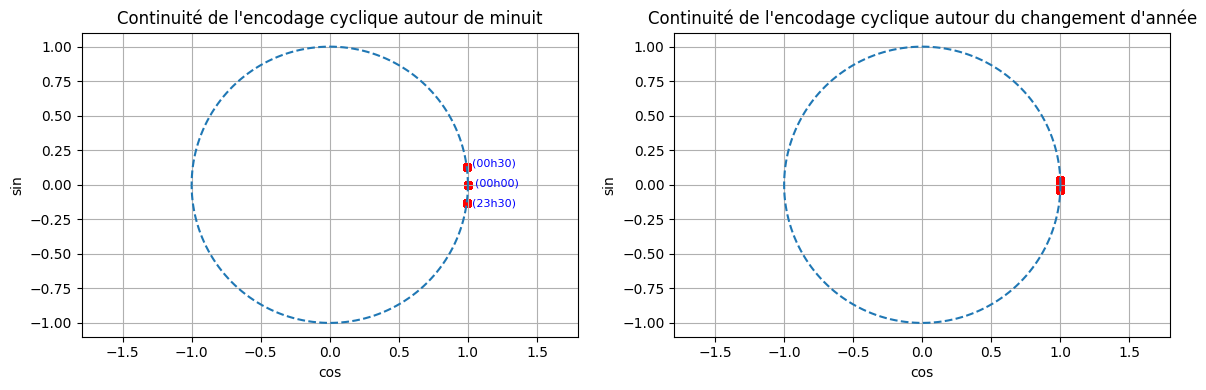

In [9]:
# Masques autour des discontinuités apparentes
mask_hour = (hour < 1) | (hour > 23)
mask_day  = (doy < 3) | (doy > (year_len - 3))

theta = np.linspace(0, 2*np.pi, 360)

plt.figure(figsize=(12, 4))

# --- Subplot 1 : Continuité autour de minuit ---
plt.subplot(1, 2, 1)
plt.scatter(df.loc[mask_hour, 'cos_hour'],
            df.loc[mask_hour, 'sin_hour'],
            color='red', s=30)

plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
plt.axis('equal')
plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Continuité de l'encodage cyclique autour de minuit")
plt.grid(True)

plt.text(1.05, -0.01, f"(00h00)", fontsize=8, color='blue')
plt.text(1.03, 0.13, f"(00h30)", fontsize=8, color='blue')
plt.text(1.03, -0.16, f"(23h30)", fontsize=8, color='blue')

# --- Subplot 2 : Continuité autour du changement d'année ---
plt.subplot(1, 2, 2)
plt.scatter(df.loc[mask_day, 'cos_day'],
            df.loc[mask_day, 'sin_day'],
            color='red', s=30)

plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
plt.axis('equal')
plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Continuité de l'encodage cyclique autour du changement d'année")
plt.grid(True)

plt.tight_layout()
plt.show()


L'utilisation d'un encodage cyclique basé sur les fonctions sinus et cosinus permet de préserver la continuité temporelle de l'heure, notamment autour de la transition minuit, contrairement à un encodage linéaire classique.


In [10]:
df.loc[
    df["ghi_region"] > 0,
    [
        "Date",
        "tch",
        "ghi_region",
        "cloud_cover_region",
        "dghi_dt",
        "dtch_dt",
        "dcloud_dt",
        "sin_hour",
        "cos_hour",
        "target_variability",
    ]
]
# df.loc[df['GHI_region'] > 0,['Date', 'TCH', 'GHI_region', 'Nebulosite_region', 'Delta_GHI','Delta_TCH', 'Delta_Nebulosite', 'sin_hour', 'cos_hour', 'sin_day', 'cos_day', 'V(t)'   ]]

,Date,tch,ghi_region,cloud_cover_region,dghi_dt,dtch_dt,dcloud_dt,sin_hour,cos_hour,target_variability
16,2020-01-01 07:00:00+00:00,0.00,0.005586,25.32550,0.005586,0.00,-3.03955,0.965926,-0.258819,0.00
17,2020-01-01 07:30:00+00:00,0.52,9.671917,22.04280,9.666331,0.52,-3.28270,0.923880,-0.382683,0.52
18,2020-01-01 08:00:00+00:00,5.22,41.024514,18.76010,31.352597,4.70,-3.28270,0.866025,-0.500000,4.70
19,2020-01-01 08:30:00+00:00,13.11,76.905586,15.77695,35.881072,7.89,-2.98315,0.793353,-0.608761,7.89
20,2020-01-01 09:00:00+00:00,22.06,111.046611,12.79380,34.141025,8.95,-2.98315,0.707107,-0.707107,8.95
...,...,...,...,...,...,...,...,...,...,...
87678,2024-12-31 14:00:00+00:00,29.64,130.798456,21.69320,-26.396737,-4.15,-0.90320,-0.500000,-0.866025,4.15
87679,2024-12-31 14:30:00+00:00,22.19,98.582465,21.22015,-32.215991,-7.45,-0.47305,-0.608761,-0.793353,7.45
87680,2024-12-31 15:00:00+00:00,13.81,63.783018,20.74710,-34.799447,-8.38,-0.47305,-0.707107,-0.707107,8.38
87681,2024-12-31 15:30:00+00:00,5.86,29.847971,19.58040,-33.935047,-7.95,-1.16670,-0.793353,-0.608761,7.95


### Encodage temporel et saisonnalité

La production photovoltaïque est fortement influencée par des phénomènes saisonniers liés à la trajectoire solaire, à la durée du jour et aux régimes météorologiques dominants. Afin d’intégrer cette dimension structurelle, des variables d’encodage temporel ont été introduites pour représenter explicitement la position du système dans le cycle annuel.

Soit $t$ un instant donné de la série temporelle. Le **jour de l’année**, noté $d(t) \in \{1, \dots, 365\}$, permet de capturer la saisonnalité fine de la production solaire, en tenant compte des variations progressives de l’ensoleillement au cours de l’année.

Afin de représenter cette saisonnalité de manière continue et exploitable par les modèles, une transformation trigonométrique est appliquée :

$$
\text{sin\_doy}(t) = \sin\left(2\pi \frac{d(t)}{365}\right), \qquad
\text{cos\_doy}(t) = \cos\left(2\pi \frac{d(t)}{365}\right)
$$

Cette représentation permet de préserver la circularité du cycle annuel, en assurant une continuité entre la fin et le début de l’année.

En complément, une variable catégorielle représentant la **saison météorologique** (hiver, printemps, été, automne) est introduite afin de distinguer des régimes de variabilité structurellement différents. Ces variables temporelles permettent au modèle de contextualiser les fluctuations observées et d’éviter de confondre des comportements saisonniers normaux avec des anomalies.

In [11]:
# -------------------------------------------------------------------
# Encodage temporel et saisonnalité
# -------------------------------------------------------------------

# Jour de l'année
df["day_of_year"] = df["Date"].dt.dayofyear

# Encodage cyclique du jour de l'année
df["sin_doy"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["cos_doy"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# Saison météorologique (catégorielle)
def season_from_month(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "fall"

df["season"] = df["Date"].dt.month.map(season_from_month)

In [12]:
# Enregistrement du dataframe version notebook colab
df_model = df.dropna().copy()
df_model.to_csv("dataset_pv_variability_paca_2020_2024.csv")